# Stage 2 Baseline: EfficientNet-B3 — İnme Arter Sınıflandırması (ACA vs MCA vs PCA)

## Cascaded Yaklaşım — Stage 2
Bu notebook, iki aşamalı (cascaded) sınıflandırma sisteminin **ikinci aşamasıdır**. Stage 1'de "Stroke" olarak tespit edilen görüntüler bu modele girer ve hangi arterde inme olduğu sınıflandırılır.

## Hipotez
Normal sınıfı çıkarıldığında model, 3 inme türü arasındaki ince anatomik farkları daha iyi öğrenecektir. 4-sınıf yaklaşımda gözlenen PCA-Normal karışıklığı ve tahterevalli etkisi ortadan kalkacaktır.

## Veri Dağılımı (Sadece Stroke — Normal Dahil Değil)

| Sınıf | Örnek Sayısı | Oran (%) | Durum |
|-------|-------------|----------|-------|
| ACA | 372 | 8.1% | Kritik düşük |
| MCA | 3269 | 70.9% | Dominant |
| PCA | 968 | 21.0% | Orta |
| **Toplam** | **4609** | **100%** | |

**Dengesizlik:** MCA:ACA = 8.79:1, PCA:ACA = 2.60:1

## Kullanılan Yöntemler
- **Model**: EfficientNet-B3 (ImageNet pretrained), ~12M parametre
- **Input**: 300x300 piksel
- **Veri Dengeleme**: WeightedRandomSampler (1/count ağırlıkları)
- **Augmentasyon**: PROJE_PLANI.md'ye uygun güvenli MRI augmentasyonları (Albumentations)
- **Loss**: CrossEntropyLoss (class_weight yok, sampler ile dengeleme)
- **Optimizer**: AdamW (lr=1e-4, weight_decay=1e-4)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=5)

## Hedef Metrikler

| Metrik | Minimum Hedef | İdeal Hedef |
|--------|---------------|-------------|
| ACA Recall | ≥ 0.85 | ≥ 0.92 |
| PCA Recall | ≥ 0.80 | ≥ 0.88 |
| MCA Recall | ≥ 0.85 | ≥ 0.90 |
| Macro Recall | ≥ 0.83 | ≥ 0.90 |
| Macro F1 | ≥ 0.80 | ≥ 0.88 |

## 4-Sınıf Yaklaşımdan Farklar
- Normal sınıfı **tamamen çıkarıldı** → PCA-Normal karışıklığı yok
- NUM_CLASSES: 4 → 3
- Toplam veri: 5524 → 4609 (sadece stroke görüntüleri)
- Model, inme türleri arasındaki anatomik farkları öğrenmeye odaklanıyor

## Bölüm 1: Setup & Imports

In [1]:
# =========================
# TEMEL KÜTÜPHANELER
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Görüntü işleme
from PIL import Image

# Metrikler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from tqdm import tqdm
from collections import Counter

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


In [2]:
# =========================
# SEED AYARLARI (Reproducibility)
# =========================
SEED = 42

def set_seed(seed):
    """Tüm random seed'leri ayarla."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f'Seed ayarlandı: {SEED}')

Seed ayarlandı: 42


In [3]:
# =========================
# DEVICE KONFİGÜRASYONU
# =========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')

if torch.cuda.is_available():
    print(f'GPU sayısı: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Kullanılan cihaz: cuda
GPU sayısı: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## Bölüm 2: Sabitler ve Hiperparametreler

In [4]:
# =========================
# SABİTLER VE HİPERPARAMETRELER
# =========================

# Veri yolu (Kaggle) — Sadece stroke görüntüleri, Normal YOK
STROKE_IMAGES_DIR = '/kaggle/input/stroke-images/flattened_images'

# Sınıf bilgileri (Normal sınıfı YOK — Stage 2)
CLASS_NAMES = ['ACA', 'MCA', 'PCA']
NUM_CLASSES = len(CLASS_NAMES)

# Model-spesifik parametreler (EfficientNet-B3)
IMG_SIZE = 300
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100
PATIENCE = 15

# Veri bölme oranları
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print('=== Stage 2 — EfficientNet-B3 Baseline Parametreleri ===')
print(f'Cascaded Stage: 2 (İnme Arter Sınıflandırması)')
print(f'Görüntü boyutu: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Weight decay: {WEIGHT_DECAY}')
print(f'Max epochs: {NUM_EPOCHS}')
print(f'Early stopping patience: {PATIENCE}')
print(f'Sınıf sayısı: {NUM_CLASSES} (Normal YOK)')
print(f'Sınıflar: {CLASS_NAMES}')

=== Stage 2 — EfficientNet-B3 Baseline Parametreleri ===
Cascaded Stage: 2 (İnme Arter Sınıflandırması)
Görüntü boyutu: 300x300
Batch size: 16
Learning rate: 0.0001
Weight decay: 0.0001
Max epochs: 100
Early stopping patience: 15
Sınıf sayısı: 3 (Normal YOK)
Sınıflar: ['ACA', 'MCA', 'PCA']


## Bölüm 3: Veri Yükleme

**Stage 2 Farkı:** Normal sınıfı dahil edilmez. Sadece stroke alt dizinlerinden (ACA, MCA, PCA) görüntüler toplanır.

In [5]:
# =========================
# VERİ YÜKLEME (Sadece Stroke — Normal YOK)
# =========================
def collect_stroke_image_paths(stroke_dir, class_names):
    """
    Stage 2 için sadece stroke görüntülerini toplar.
    Normal sınıfı dahil edilmez.
    """
    image_paths = []
    labels = []
    
    for idx, class_name in enumerate(class_names):
        class_dir = Path(stroke_dir) / class_name
        
        if not class_dir.exists():
            print(f'Uyarı: {class_dir} dizini bulunamadı!')
            continue
        
        extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff',
                      '*.PNG', '*.JPG', '*.JPEG', '*.BMP', '*.TIF', '*.TIFF']
        
        class_images = []
        for ext in extensions:
            class_images.extend(list(class_dir.glob(ext)))
        
        print(f'{class_name}: {len(class_images)} görüntü')
        
        for img_path in class_images:
            image_paths.append(str(img_path))
            labels.append(idx)
    
    return np.array(image_paths), np.array(labels)

all_image_paths, all_labels = collect_stroke_image_paths(
    STROKE_IMAGES_DIR, CLASS_NAMES
)

print(f'\nToplam stroke görüntü sayısı: {len(all_image_paths)}')
print(f'Normal sınıfı dahil edilmedi (Stage 2).')

ACA: 372 görüntü
MCA: 3269 görüntü
PCA: 968 görüntü

Toplam stroke görüntü sayısı: 4609
Normal sınıfı dahil edilmedi (Stage 2).


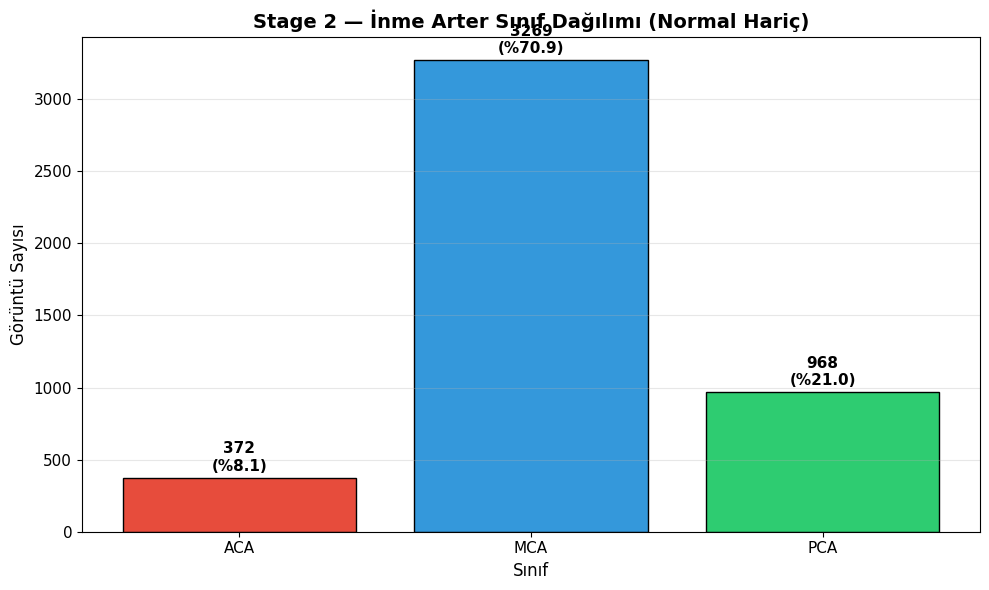


Sınıf Dengesizlik Oranları:
  ACA:ACA = 1.00:1
  MCA:ACA = 8.79:1
  PCA:ACA = 2.60:1


In [6]:
# =========================
# SINIF DAĞILIMI GÖRSELLEŞTİRME
# =========================
class_counts = Counter(all_labels)
class_distribution = {CLASS_NAMES[k]: v for k, v in sorted(class_counts.items())}

plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = plt.bar(class_distribution.keys(), class_distribution.values(),
               color=colors, edgecolor='black')
plt.xlabel('Sınıf', fontsize=12)
plt.ylabel('Görüntü Sayısı', fontsize=12)
plt.title('Stage 2 — İnme Arter Sınıf Dağılımı (Normal Hariç)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)

for bar, (k, v) in zip(bars, class_distribution.items()):
    pct = v / len(all_labels) * 100
    plt.text(bar.get_x() + bar.get_width()/2, v + 50,
             f'{v}\n(%{pct:.1f})',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Dengesizlik oranları
print('\nSınıf Dengesizlik Oranları:')
aca_count = class_distribution['ACA']
for name, count in class_distribution.items():
    ratio = count / aca_count
    print(f'  {name}:ACA = {ratio:.2f}:1')

## Bölüm 4: Stratified Train/Val/Test Split

In [7]:
# =========================
# STRATIFIED TRAIN/VAL/TEST SPLIT
# =========================
# 70/15/15 oranında stratified split

X_temp, X_test, y_temp, y_test = train_test_split(
    all_image_paths, all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=SEED
)

val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio_adjusted,
    stratify=y_temp,
    random_state=SEED
)

print('Stratified split tamamlandı.')
print(f'Train: {len(X_train)} ({len(X_train)/len(all_image_paths)*100:.1f}%)')
print(f'Val:   {len(X_val)} ({len(X_val)/len(all_image_paths)*100:.1f}%)')
print(f'Test:  {len(X_test)} ({len(X_test)/len(all_image_paths)*100:.1f}%)')

for split_name, split_labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'\n--- {split_name} Sınıf Dağılımı ---')
    for c_idx, cnt in sorted(Counter(split_labels).items()):
        print(f'  {CLASS_NAMES[c_idx]}: {cnt}')

Stratified split tamamlandı.
Train: 3225 (70.0%)
Val:   692 (15.0%)
Test:  692 (15.0%)

--- Train Sınıf Dağılımı ---
  ACA: 260
  MCA: 2287
  PCA: 678

--- Val Sınıf Dağılımı ---
  ACA: 56
  MCA: 491
  PCA: 145

--- Test Sınıf Dağılımı ---
  ACA: 56
  MCA: 491
  PCA: 145


## Bölüm 5: Augmentasyon (Medikal MRI İçin Güvenli)

**YASAKLAR (Medikal Güvenlik):**
- VerticalFlip: Beyin yukarı-aşağı simetrik değil
- GaussianBlur: DWI'da lezyon sınırlarını eritir
- CutMix: Küçük ACA lezyonlarını kapatabilir

In [8]:
# =========================
# AUGMENTASYON (Albumentations — Medikal Güvenli)
# =========================

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # === GEOMETRİK (Güvenli) ===
    A.HorizontalFlip(p=0.5),
    A.Rotate(
        limit=15,
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0
    ),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.1,
        rotate_limit=0,
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0
    ),

    # === ELASTİK DEFORMASYON (Anatomik varyasyon) ===
    A.ElasticTransform(
        alpha=50,
        sigma=50 * 0.05,
        p=0.3
    ),
    A.GridDistortion(
        num_steps=5,
        distort_limit=0.1,
        p=0.3
    ),

    # === INTENSITY (Dikkatli limitler) ===
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.3
    ),
    A.GaussNoise(
        var_limit=(5.0, 20.0),
        p=0.2
    ),

    # === NORMALİZASYON ===
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2(),
])

print('Augmentasyon pipeline tanımlandı.')
print('\nTrain augmentasyonları:')
print('  ✅ HorizontalFlip (p=0.5)')
print('  ✅ Rotate (limit=15°, p=0.5)')
print('  ✅ ShiftScaleRotate (shift=0.1, scale=0.1, p=0.5)')
print('  ✅ ElasticTransform (p=0.3)')
print('  ✅ GridDistortion (p=0.3)')
print('  ✅ RandomBrightnessContrast (limit=0.1, p=0.3)')
print('  ✅ GaussNoise (p=0.2)')
print('\nYASAKLAR:')
print('  ❌ VerticalFlip (beyin anatomisi)')
print('  ❌ GaussianBlur (lezyon sınırları)')
print('  ❌ CutMix (küçük lezyon kaybı)')

Augmentasyon pipeline tanımlandı.

Train augmentasyonları:
  ✅ HorizontalFlip (p=0.5)
  ✅ Rotate (limit=15°, p=0.5)
  ✅ ShiftScaleRotate (shift=0.1, scale=0.1, p=0.5)
  ✅ ElasticTransform (p=0.3)
  ✅ GridDistortion (p=0.3)
  ✅ RandomBrightnessContrast (limit=0.1, p=0.3)
  ✅ GaussNoise (p=0.2)

YASAKLAR:
  ❌ VerticalFlip (beyin anatomisi)
  ❌ GaussianBlur (lezyon sınırları)
  ❌ CutMix (küçük lezyon kaybı)


## Bölüm 6: Dataset Sınıfı ve DataLoader

In [9]:
# =========================
# DATASET SINIFI
# =========================
class StrokeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = int(self.labels[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

train_dataset = StrokeDataset(X_train, y_train, transform=train_transform)
val_dataset = StrokeDataset(X_val, y_val, transform=val_transform)
test_dataset = StrokeDataset(X_test, y_test, transform=val_transform)

print('Dataset\'ler oluşturuldu:')
print(f'  Train: {len(train_dataset)} örnek')
print(f'  Val:   {len(val_dataset)} örnek')
print(f'  Test:  {len(test_dataset)} örnek')

Dataset'ler oluşturuldu:
  Train: 3225 örnek
  Val:   692 örnek
  Test:  692 örnek


## Bölüm 7: WeightedRandomSampler ve DataLoader

In [10]:
# =========================
# WEIGHTED RANDOM SAMPLER
# =========================
class_counts_train = Counter(y_train)
print('Train sınıf sayıları:')
for c_idx in range(NUM_CLASSES):
    print(f'  {CLASS_NAMES[c_idx]}: {class_counts_train[c_idx]}')

class_weights_sampler = {}
for c_idx in range(NUM_CLASSES):
    class_weights_sampler[c_idx] = 1.0 / class_counts_train[c_idx]

print('\nSampler için sınıf ağırlıkları (1/count):')
for c_idx, w in class_weights_sampler.items():
    print(f'  {CLASS_NAMES[c_idx]}: {w:.6f}')

sample_weights = [class_weights_sampler[int(label)] for label in y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print('\nWeightedRandomSampler oluşturuldu.')

# =========================
# DATALOADER (DÜZELTİLMİŞ)
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    drop_last=True  # <--- BU SATIR EKLENDİ (Hata önleyici)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f'\nDataLoader\'lar hazır:')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches:   {len(val_loader)}')
print(f'  Test batches:  {len(test_loader)}')

Train sınıf sayıları:
  ACA: 260
  MCA: 2287
  PCA: 678

Sampler için sınıf ağırlıkları (1/count):
  ACA: 0.003846
  MCA: 0.000437
  PCA: 0.001475

WeightedRandomSampler oluşturuldu.

DataLoader'lar hazır:
  Train batches: 201
  Val batches:   44
  Test batches:  44


## Bölüm 8: Model Tanımı — EfficientNet-B3

In [11]:
# =========================
# EFFICIENTNET-B3 MODEL TANIMI (DÜZELTİLMİŞ - TEK GPU)
# =========================
def create_efficientnet_b3(num_classes, pretrained=True):
    if pretrained:
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        model = models.efficientnet_b3(weights=weights)
    else:
        model = models.efficientnet_b3(weights=None)

    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_features, num_classes)
    )

    return model

model = create_efficientnet_b3(NUM_CLASSES, pretrained=True)

# --- DEĞİŞİKLİK: DataParallel KODU SİLİNDİ ---
# Modeli doğrudan tanımlanan cihaza gönderiyoruz
model = model.to(device)
# ---------------------------------------------

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('EfficientNet-B3 modeli oluşturuldu (Single GPU Mode).')
print(f'  Toplam parametre: {total_params:,}')
print(f'  Eğitilebilir parametre: {trainable_params:,}')
print(f'  Çıkış sınıf sayısı: {NUM_CLASSES} (ACA, MCA, PCA)')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 147MB/s] 


EfficientNet-B3 modeli oluşturuldu (Single GPU Mode).
  Toplam parametre: 10,700,843
  Eğitilebilir parametre: 10,700,843
  Çıkış sınıf sayısı: 3 (ACA, MCA, PCA)


## Bölüm 9: Loss, Optimizer, Scheduler

In [12]:
# =========================
# LOSS, OPTIMIZER, SCHEDULER
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print('Loss: CrossEntropyLoss (class_weight yok, sampler ile dengeleme)')
print('Optimizer: AdamW')
print(f'  - Learning rate: {LEARNING_RATE}')
print(f'  - Weight decay: {WEIGHT_DECAY}')
print('Scheduler: ReduceLROnPlateau')
print('  - Factor: 0.5')
print('  - Patience: 5')

Loss: CrossEntropyLoss (class_weight yok, sampler ile dengeleme)
Optimizer: AdamW
  - Learning rate: 0.0001
  - Weight decay: 0.0001
Scheduler: ReduceLROnPlateau
  - Factor: 0.5
  - Patience: 5


## Bölüm 10: Eğitim Fonksiyonları

In [13]:
# =========================
# EĞİTİM FONKSİYONLARI
# =========================
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation', leave=False)
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100*correct/total:.2f}%'
            })

    avg_loss = running_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

print('Eğitim fonksiyonları tanımlandı.')

Eğitim fonksiyonları tanımlandı.


## Bölüm 11: Eğitim Döngüsü + Early Stopping

In [14]:
# =========================
# EĞİTİM DÖNGÜSÜ + EARLY STOPPING (VERBOSE EKLENDİ)
# =========================
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0
# Modeli RAM'de tutmak yerine diske kaydetmek daha güvenlidir (Colab/Kaggle çökmesine karşı)
CHECKPOINT_PATH = 'best_model.pth' 

print('Stage 2 — EfficientNet-B3 eğitimi başlıyor...\n')
print('=' * 70)

for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 70)

    # --- Training ---
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # --- Validation ---
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(
        model, val_loader, criterion, device
    )

    # --- Scheduler Step ve VERBOSE Kontrolü ---
    # Mevcut learning rate'i al
    current_lr = optimizer.param_groups[0]['lr']
    
    # Scheduler'ı güncelle
    scheduler.step(val_loss)
    
    # Yeni learning rate'i al
    new_lr = optimizer.param_groups[0]['lr']
    
    # Eğer LR değiştiyse ekrana yazdır (Verbose işlemi)
    if new_lr != current_lr:
        print(f"    >>> Learning Rate Düştü: {current_lr:.2e} -> {new_lr:.2e}")

    # --- History Kayıt ---
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%')
    print(f'Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc*100:.2f}%')

    # --- Early Stopping ve Checkpoint ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Modeli diske kaydet
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f'>>> En iyi model kaydedildi (Val Loss: {val_loss:.4f})')
    else:
        patience_counter += 1
        print(f'Early stopping counter: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping! {PATIENCE} epoch boyunca iyileşme olmadı.')
        break

    print('=' * 70)

# Eğitim bittiğinde en iyi modeli yükle
if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH))
    print('\nEn iyi model ağırlıkları yüklendi.')

Stage 2 — EfficientNet-B3 eğitimi başlıyor...

Epoch 1/100
----------------------------------------------------------------------


Train Loss: 0.9746, Train Acc: 50.78%
Val   Loss: 0.9252, Val   Acc: 51.59%
>>> En iyi model kaydedildi (Val Loss: 0.9252)
Epoch 2/100
----------------------------------------------------------------------


Train Loss: 0.7413, Train Acc: 67.32%
Val   Loss: 0.6052, Val   Acc: 73.70%
>>> En iyi model kaydedildi (Val Loss: 0.6052)
Epoch 3/100
----------------------------------------------------------------------


Train Loss: 0.6049, Train Acc: 74.84%
Val   Loss: 0.6287, Val   Acc: 72.40%
Early stopping counter: 1/15
Epoch 4/100
----------------------------------------------------------------------


Train Loss: 0.5391, Train Acc: 77.52%
Val   Loss: 0.3899, Val   Acc: 83.82%
>>> En iyi model kaydedildi (Val Loss: 0.3899)
Epoch 5/100
----------------------------------------------------------------------


...

Train Loss: 0.1488, Train Acc: 94.40%
Val   Loss: 0.3665, Val   Acc: 89.16%
Early stopping counter: 11/15
Epoch 28/100
----------------------------------------------------------------------


    >>> Learning Rate Düştü: 5.00e-05 -> 2.50e-05
Train Loss: 0.1421, Train Acc: 94.65%
Val   Loss: 0.3788, Val   Acc: 90.03%
Early stopping counter: 12/15
Epoch 29/100
----------------------------------------------------------------------


Train Loss: 0.1514, Train Acc: 94.47%
Val   Loss: 0.3405, Val   Acc: 90.03%
Early stopping counter: 13/15
Epoch 30/100
----------------------------------------------------------------------


Train Loss: 0.1366, Train Acc: 94.65%
Val   Loss: 0.3489, Val   Acc: 90.32%
Early stopping counter: 14/15
Epoch 31/100
----------------------------------------------------------------------


Train Loss: 0.1349, Train Acc: 94.53%
Val   Loss: 0.3374, Val   Acc: 90.03%
Early stopping counter: 15/15

Early stopping! 15 epoch boyunca iyileşme olmadı.

En iyi model ağırlıkları yüklendi.


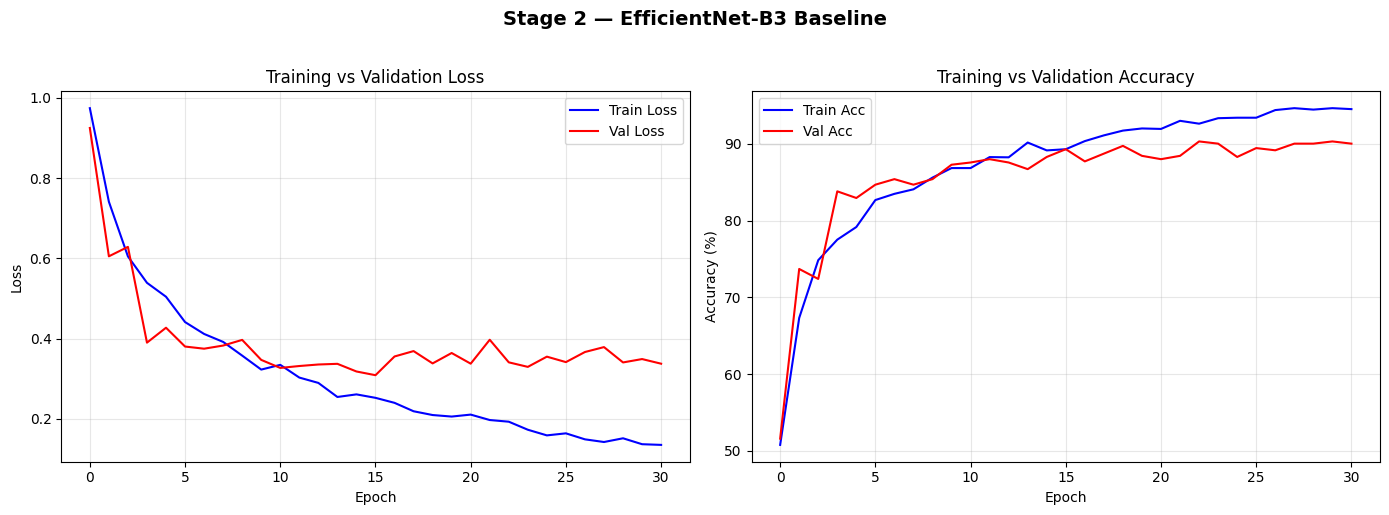

In [15]:
# =========================
# EĞİTİM GRAFİKLERİ
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([acc*100 for acc in history['train_acc']], label='Train Acc', color='blue')
axes[1].plot([acc*100 for acc in history['val_acc']], label='Val Acc', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Stage 2 — EfficientNet-B3 Baseline', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Bölüm 12: Test Değerlendirmesi

In [16]:
# =========================
# TEST DEĞERLENDİRMESİ
# =========================
print('Stage 2 — EfficientNet-B3 Test Değerlendirmesi')
print('=' * 70)

test_loss, test_acc, test_preds, test_labels, test_probs = validate(
    model, test_loader, criterion, device
)

print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')

Stage 2 — EfficientNet-B3 Test Değerlendirmesi



Test Loss: 0.3321
Test Accuracy: 89.02%


In [17]:
# =========================
# CLASSIFICATION REPORT
# =========================
print('\nSınıf Bazlı Metrikler (Classification Report):')
print('=' * 70)
print(classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES,
    digits=4
))


Sınıf Bazlı Metrikler (Classification Report):
              precision    recall  f1-score   support

         ACA     0.7544    0.7679    0.7611        56
         MCA     0.9504    0.8982    0.9236       491
         PCA     0.7719    0.9103    0.8354       145

    accuracy                         0.8902       692
   macro avg     0.8256    0.8588    0.8400       692
weighted avg     0.8972    0.8902    0.8919       692



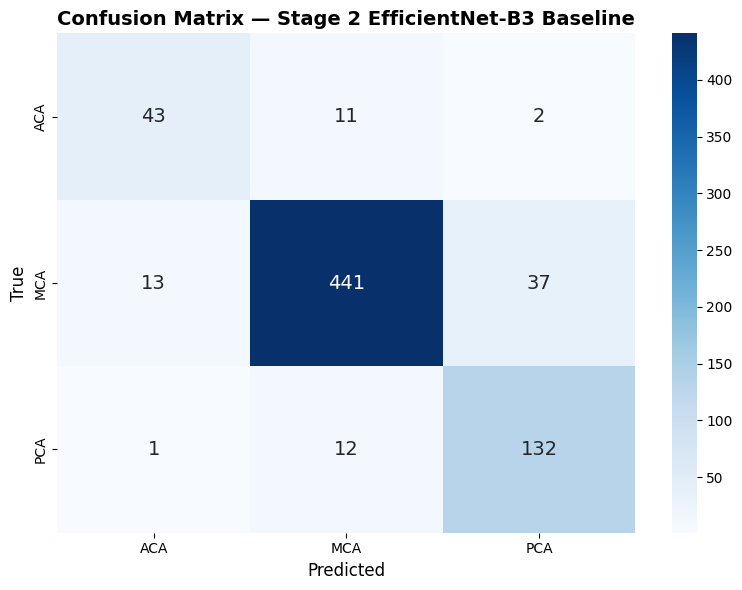

In [18]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={'size': 14}
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix — Stage 2 EfficientNet-B3 Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# =========================
# PER-CLASS RECALL + MACRO METRİKLER
# =========================
print('Sınıf Bazlı Recall Değerleri:')
print('=' * 50)

recall_per_class = recall_score(test_labels, test_preds, average=None)

for idx, (name, recall) in enumerate(zip(CLASS_NAMES, recall_per_class)):
    status = '<<< KRİTİK' if name == 'ACA' else ''
    print(f'  {name}: {recall:.4f} {status}')

macro_f1 = f1_score(test_labels, test_preds, average='macro')
macro_recall = recall_score(test_labels, test_preds, average='macro')
macro_precision = precision_score(test_labels, test_preds, average='macro')

print('\n' + '=' * 50)
print('MACRO METRİKLER:')
print(f'  Macro Precision: {macro_precision:.4f}')
print(f'  Macro Recall:    {macro_recall:.4f}')
print(f'  Macro F1:        {macro_f1:.4f}')

Sınıf Bazlı Recall Değerleri:
  ACA: 0.7679 <<< KRİTİK
  MCA: 0.8982 
  PCA: 0.9103 

MACRO METRİKLER:
  Macro Precision: 0.8256
  Macro Recall:    0.8588
  Macro F1:        0.8400


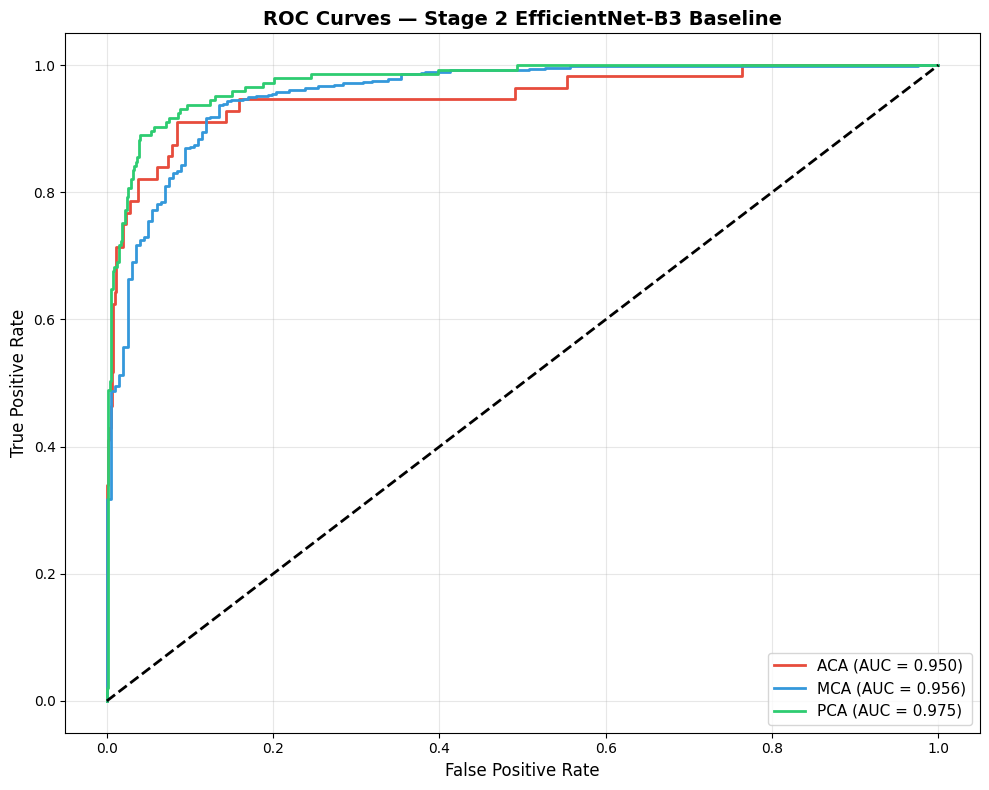

In [20]:
# =========================
# ROC CURVES
# =========================
y_true_bin = label_binarize(test_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Stage 2 EfficientNet-B3 Baseline', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bölüm 13: Sonuç Özeti

In [21]:
# =========================
# SONUÇ ÖZETİ
# =========================
print('=' * 70)
print('STAGE 2 — EfficientNet-B3 BASELINE — SONUÇ ÖZETİ')
print('=' * 70)

print('\n--- Model Bilgileri ---')
print(f'Model: EfficientNet-B3')
print(f'Parametre sayısı: ~12M')
print(f'Input boyutu: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Stage: 2 (İnme Arter Sınıflandırması — Normal YOK)')

print('\n--- Eğitim Bilgileri ---')
print(f'Toplam epoch: {len(history["train_loss"])}')
print(f'En iyi Val Loss: {best_val_loss:.4f}')
print(f'Final Learning Rate: {optimizer.param_groups[0]["lr"]}')

print('\n--- Test Sonuçları ---')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

print('\n--- Sınıf Bazlı Recall ---')
for name, recall in zip(CLASS_NAMES, recall_per_class):
    target = '(Hedef: ≥0.85)' if name == 'ACA' else '(Hedef: ≥0.80)' if name == 'PCA' else '(Hedef: ≥0.85)'
    print(f'  {name}: {recall:.4f} {target}')

print('\n--- Macro Metrikler ---')
print(f'Macro Recall: {macro_recall:.4f} (Hedef: ≥0.83)')
print(f'Macro F1:     {macro_f1:.4f} (Hedef: ≥0.80)')

print('\n--- Hedef Karşılaştırması ---')
aca_recall = recall_per_class[0]
pca_recall = recall_per_class[2]
print(f'ACA Recall:   {"✓" if aca_recall >= 0.85 else "✗"} ({aca_recall:.4f} vs 0.85)')
print(f'PCA Recall:   {"✓" if pca_recall >= 0.80 else "✗"} ({pca_recall:.4f} vs 0.80)')
print(f'Macro Recall: {"✓" if macro_recall >= 0.83 else "✗"} ({macro_recall:.4f} vs 0.83)')
print(f'Macro F1:     {"✓" if macro_f1 >= 0.80 else "✗"} ({macro_f1:.4f} vs 0.80)')

print('\n' + '=' * 70)

STAGE 2 — EfficientNet-B3 BASELINE — SONUÇ ÖZETİ

--- Model Bilgileri ---
Model: EfficientNet-B3
Parametre sayısı: ~12M
Input boyutu: 300x300
Batch size: 16
Stage: 2 (İnme Arter Sınıflandırması — Normal YOK)

--- Eğitim Bilgileri ---
Toplam epoch: 31
En iyi Val Loss: 0.3087
Final Learning Rate: 2.5e-05

--- Test Sonuçları ---
Test Accuracy: 89.02%
Test Loss: 0.3321

--- Sınıf Bazlı Recall ---
  ACA: 0.7679 (Hedef: ≥0.85)
  MCA: 0.8982 (Hedef: ≥0.85)
  PCA: 0.9103 (Hedef: ≥0.80)

--- Macro Metrikler ---
Macro Recall: 0.8588 (Hedef: ≥0.83)
Macro F1:     0.8400 (Hedef: ≥0.80)

--- Hedef Karşılaştırması ---
ACA Recall:   ✗ (0.7679 vs 0.85)
PCA Recall:   ✓ (0.9103 vs 0.80)
Macro Recall: ✓ (0.8588 vs 0.83)
Macro F1:     ✓ (0.8400 vs 0.80)

